In [5]:
import pandas as pd

In [14]:
df = pd.read_csv("Banque")
df.head(30)

,transaction_id,date,compte,marchand,pays,montant_eur,heure,jour_semaine,mois,flag_montant,flag_pays,flag_heure,mois_annee,flag_freq,nb_flags,score_risque,niveau_risque
0,TXN00317,2024-01-01 04:30:00,FR27267998696,Saturn,Allemagne,4952.60,4,Monday,1,False,False,True,2024-01,False,1,15,Faible
1,TXN00171,2024-01-01 19:22:00,FR35992864987,SNCB,Belgique,836.05,19,Monday,1,False,False,False,2024-01,False,0,0,Normal
2,TXN00421,2024-01-04 02:45:00,FR20481423238,Carrefour,France,461.74,2,Thursday,1,False,False,True,2024-01,False,1,15,Faible
3,TXN00432,2024-01-04 11:19:00,FR95537499593,Trenitalia,Italie,1707.63,11,Thursday,1,False,False,False,2024-01,False,0,0,Normal
4,TXN00106,2024-01-05 03:04:00,FR58542293886,SBB,Suisse,1808.34,3,Friday,1,False,False,True,2024-01,False,1,15,Faible
5,TXN00042,2024-01-05 03:44:00,FR99792454597,NS Spoorwegen,Pays-Bas,1404.45,3,Friday,1,False,False,True,2024-01,False,1,15,Faible
6,TXN00186,2024-01-05 18:55:00,FR58555469429,Albert Heijn,Pays-Bas,1490.61,18,Friday,1,False,False,False,2024-01,False,0,0,Normal
7,TXN00151,2024-01-09 05:16:00,FR45501239256,Lidl DE,Allemagne,1484.73,5,Tuesday,1,False,False,False,2024-01,False,0,0,Normal
8,TXN00088,2024-01-09 11:21:00,FR58555469429,SNCF,France,1959.90,11,Tuesday,1,False,False,False,2024-01,False,0,0,Normal
9,TXN00084,2024-01-12 09:29:00,FR58555469429,SBB,Suisse,1091.17,9,Friday,1,False,False,False,2024-01,False,0,0,Normal


In [9]:
df["pays"].value_counts()
# j'ai compter les pays ou il y a le plus de candidats

pays
Italie           88
Suisse           82
Pays-Bas         78
Espagne          72
Belgique         65
Allemagne        61
France           54
Venezuela         6
Biélorussie       5
Iran              5
Corée du Nord     4
Russie            4
Nigeria           4
Myanmar           2
Name: count, dtype: int64

In [10]:
df.shape

(530, 17)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  530 non-null    object 
 1   date            530 non-null    object 
 2   compte          530 non-null    object 
 3   marchand        530 non-null    object 
 4   pays            530 non-null    object 
 5   montant_eur     530 non-null    float64
 6   heure           530 non-null    int64  
 7   jour_semaine    530 non-null    object 
 8   mois            530 non-null    int64  
 9   flag_montant    530 non-null    bool   
 10  flag_pays       530 non-null    bool   
 11  flag_heure      530 non-null    bool   
 12  mois_annee      530 non-null    object 
 13  flag_freq       530 non-null    bool   
 14  nb_flags        530 non-null    int64  
 15  score_risque    530 non-null    int64  
 16  niveau_risque   530 non-null    object 
dtypes: bool(4), float64(1), int64(4), o

In [12]:
df.isnull().sum()
# les données manquants

transaction_id    0
date              0
compte            0
marchand          0
pays              0
montant_eur       0
heure             0
jour_semaine      0
mois              0
flag_montant      0
flag_pays         0
flag_heure        0
mois_annee        0
flag_freq         0
nb_flags          0
score_risque      0
niveau_risque     0
dtype: int64

In [13]:
df.describe()

,montant_eur,heure,mois,nb_flags,score_risque
count,530.000000,530.000000,530.000000,530.000000,530.000000
mean,2905.155132,11.092453,6.633962,0.367925,7.783019
std,7579.605030,7.185691,3.434229,0.531173,12.983197
min,10.340000,0.000000,1.000000,0.000000,0.000000
25%,624.565000,4.000000,4.000000,0.000000,0.000000
50%,1155.960000,11.000000,7.000000,0.000000,0.000000
75%,1729.090000,17.000000,10.000000,1.000000,15.000000
max,49688.610000,23.000000,12.000000,2.000000,55.000000


In [15]:
df.duplicated().sum()

0

In [24]:
# les transactions suspects 
df["flag_montant"].value_counts()

flag_montant
False    506
True      24
Name: count, dtype: int64

In [25]:
df["flag_heure"].value_counts()

flag_heure
False    389
True     141
Name: count, dtype: int64

In [28]:
df["flag_pays"].value_counts()

flag_pays
False    500
True      30
Name: count, dtype: int64

In [30]:
df["flag_freq"].value_counts()

flag_freq
False    530
Name: count, dtype: int64

In [31]:
# je viens de voir la variable ou la plus suspect et c'est l'heure

In [32]:
df["pays"].value_counts()

pays
Italie           88
Suisse           82
Pays-Bas         78
Espagne          72
Belgique         65
Allemagne        61
France           54
Venezuela         6
Biélorussie       5
Iran              5
Corée du Nord     4
Russie            4
Nigeria           4
Myanmar           2
Name: count, dtype: int64

In [34]:
df["marchand"].value_counts()

marchand
Mediaworld              35
Esselunga               32
Albert Heijn            32
Coop CH                 31
Migros                  31
El Corte Inglés         27
NS Spoorwegen           25
Mercadona               24
SNCB                    24
Delhaize                21
Iberia                  21
Bol.com                 21
Trenitalia              21
SBB                     20
Deutsche Bahn           20
Colruyt                 20
Amazon DE               16
Lidl DE                 13
Saturn                  12
Total Energie           10
Amazon FR               10
Décathlon                8
EDF                      8
Carrefour                7
SNCF                     6
Crypto VZ                5
FNAC                     5
Alfa Bank BY             3
Melli Bank               3
Access Bank Online       3
KBZ Bank                 2
DPRK Transfer            2
Belarusbank Transfer     2
VTB Online               2
Iran Transfer            2
Sberbank Transfer        2
Anonymous Wallet   

In [35]:
# Notre cliens fidele est monsieur "Mediaworld"

In [36]:
df["jour_semaine"].value_counts()

jour_semaine
Friday       91
Wednesday    78
Saturday     74
Sunday       74
Monday       72
Tuesday      71
Thursday     70
Name: count, dtype: int64

In [37]:
df.groupby("heure")["score_risque"].mean()
# les heures risquer 

heure
0     20.370370
1     17.500000
2     18.809524
3     20.000000
4     16.111111
5      5.789474
6      2.666667
7      4.423077
8      2.500000
9      0.000000
10     7.333333
11     1.590909
12     8.260870
13     3.947368
14     3.387097
15    10.454545
16     0.000000
17     9.250000
18     1.666667
19     5.500000
20     3.809524
21     3.478261
22     1.750000
23     2.800000
Name: score_risque, dtype: float64

In [44]:
df.groupby("pays")["score_risque"].mean()

pays
Allemagne         5.573770
Belgique          6.769231
Biélorussie      38.000000
Corée du Nord    38.750000
Espagne           7.847222
France            5.185185
Iran             41.000000
Italie            5.340909
Myanmar          35.000000
Nigeria          38.750000
Pays-Bas          6.858974
Russie           38.750000
Suisse            3.963415
Venezuela        40.000000
Name: score_risque, dtype: float64

In [51]:
df.groupby("pays")["score_risque"].mean().idxmax()

'Iran'

In [53]:
# les gros montant sont-ils a risque elevé?
df.groupby("flag_montant")["score_risque"].mean()

flag_montant
False     6.106719
True     43.125000
Name: score_risque, dtype: float64

In [54]:
# LES VISUALISATIONS
import matplotlib.pyplot as plt


Text(0, 0.5, 'effectif')

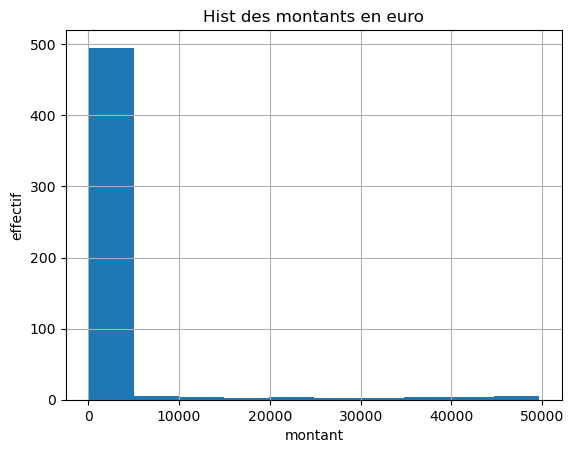

In [56]:
df["montant_eur"].hist()
plt.title("Hist des montants en euro")
plt.xlabel("montant")
plt.ylabel("effectif")

<Axes: xlabel='niveau_risque'>

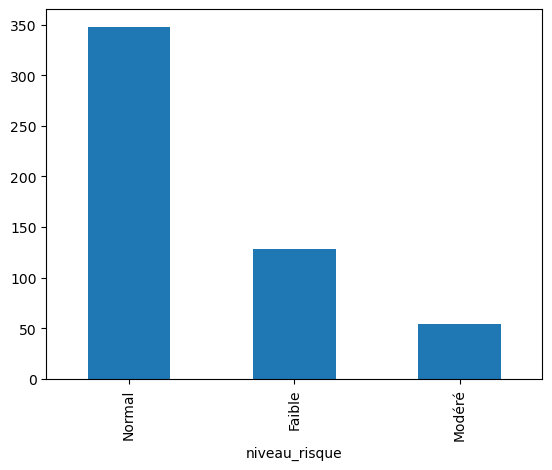

In [57]:
# Transaction par pays 
df["niveau_risque"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

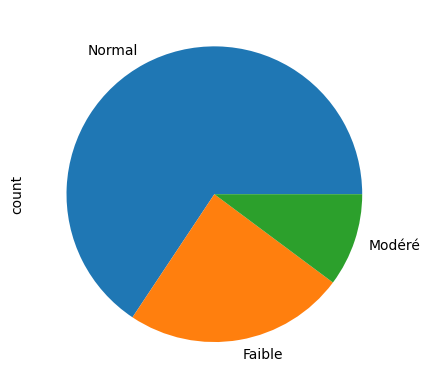

In [59]:
df["niveau_risque"].value_counts().plot(kind="pie")
# je veux revelé rapidement les anomalies, tendances cachées

In [60]:
df[df["flag_heure"] == True]
# les transactions nocturnes (on peux facilement localiser une fraude avec l'heure)

,transaction_id,date,compte,marchand,pays,montant_eur,heure,jour_semaine,mois,flag_montant,flag_pays,flag_heure,mois_annee,flag_freq,nb_flags,score_risque,niveau_risque
0,TXN00317,2024-01-01 04:30:00,FR27267998696,Saturn,Allemagne,4952.60,4,Monday,1,False,False,True,2024-01,False,1,15,Faible
2,TXN00421,2024-01-04 02:45:00,FR20481423238,Carrefour,France,461.74,2,Thursday,1,False,False,True,2024-01,False,1,15,Faible
4,TXN00106,2024-01-05 03:04:00,FR58542293886,SBB,Suisse,1808.34,3,Friday,1,False,False,True,2024-01,False,1,15,Faible
5,TXN00042,2024-01-05 03:44:00,FR99792454597,NS Spoorwegen,Pays-Bas,1404.45,3,Friday,1,False,False,True,2024-01,False,1,15,Faible
12,TXN00325,2024-01-14 02:22:00,FR47692585674,Total Energie,France,33070.83,2,Sunday,1,True,False,True,2024-01,False,2,55,Modéré
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,TXN00268,2024-12-19 03:40:00,FR98459899733,Mercadona,Espagne,738.25,3,Thursday,12,False,False,True,2024-12,False,1,15,Faible
520,TXN00020,2024-12-22 00:54:00,FR58542293886,Bol.com,Pays-Bas,1153.50,0,Sunday,12,False,False,True,2024-12,False,1,15,Faible
521,TXN00208,2024-12-22 04:48:00,FR91697731319,Esselunga,Italie,899.96,4,Sunday,12,False,False,True,2024-12,False,1,15,Faible
526,TXN00203,2024-12-28 04:00:00,FR74143483563,Delhaize,Belgique,914.74,4,Saturday,12,False,False,True,2024-12,False,1,15,Faible


In [61]:
df[df["score_risque"]>50]

,transaction_id,date,compte,marchand,pays,montant_eur,heure,jour_semaine,mois,flag_montant,flag_pays,flag_heure,mois_annee,flag_freq,nb_flags,score_risque,niveau_risque
12,TXN00325,2024-01-14 02:22:00,FR47692585674,Total Energie,France,33070.83,2,Sunday,1,True,False,True,2024-01,False,2,55,Modéré
52,TXN00234,2024-02-07 02:17:00,FR64152013905,Mediaworld,Italie,37890.44,2,Wednesday,2,True,False,True,2024-02,False,2,55,Modéré
233,TXN00194,2024-06-16 00:40:00,FR38835987236,Bol.com,Pays-Bas,49688.61,0,Sunday,6,True,False,True,2024-06,False,2,55,Modéré
335,TXN00057,2024-08-22 03:08:00,FR45110630926,Décathlon,France,47850.59,3,Thursday,8,True,False,True,2024-08,False,2,55,Modéré
488,TXN00063,2024-12-03 04:45:00,FR58258457052,Bol.com,Pays-Bas,23833.61,4,Tuesday,12,True,False,True,2024-12,False,2,55,Modéré


In [62]:
# APRES LES ANALYSE ON CONSTATE QUE :
# les transactions nocturnes ont un score de risque plus élevé
# Certains pays présentent plus d'anomalies
# Les gros montants augmentent fortement le risque 
# Certains commercants apparaissent fréquement dans les transactions suspectes 

In [ ]:
# LES RECOMMANDATIONS

# Renforcer la surveillance nocturne
# Vérifier certains commerçants
# Contrôler les transactions internationales élevé
# Augmenter les alertes automatiques